In [ ]:
!pip install transformers datasets peft accelerate trl bitsandbytes

# TinyLlama - Text generation model

TinyLlama-1.1B-Chat-v1.0  
 is a lightweight open-source large language model (LLM) designed for conversational AI and chatbot applications. It is based on the Llama architecture and contains approximately 1.1 billion parameters, making it much smaller and faster than larger models like GPT or Llama-2/3 while still providing good performance for educational and research purposes.  

Key Features  
Model Type: Transformer Decoder-based Language Model  
Architecture: Llama-style autoregressive transformer  
Parameters: 1.1 Billion  
Purpose: Chatbot and conversational AI tasks  
Training Data: Trained on around 3 trillion tokens of text data  
Efficiency: Runs on low-resource GPUs and even Google Colab free tier  
Open Source: Available publicly on Hugging Face  

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
model = AutoModelForCausalLM.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
messages = [
    {"role": "user", "content": "Who are you?"},
]

This line prepares a conversation in the format TinyLlama expects before sending it to the model. Let’s break it piece by piece:

Different chat models use different conversation templates.

TinyLlama may convert:

[
 {"role":"user","content":"What is NLP?"}
]

into something like:

<|user|>
What is NLP?

<|assistant|>

This formatting step is done automatically.

In [ ]:
inputs = tokenizer.apply_chat_template(messages,add_generation_prompt=True,tokenize=True,return_dict=True,return_tensors="pt",).to(model.device)

In [ ]:
outputs = model.generate(**inputs, max_new_tokens=40)

In [ ]:
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

I am a machine learning model that was trained on a vast dataset of human speech. I was created using advanced algorithms and artificial intelligence techniques to analyze and understand human speech patterns. My primary goal is to


In [ ]:
messages_try = [
    {"role": "user", "content": "What is the use of transformers in deep learning?"},
]

inputs = tokenizer.apply_chat_template(messages_try,add_generation_prompt=True,tokenize=True,return_dict=True,return_tensors="pt",).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=200)

print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

Transformers are a type of neural network architecture that is widely used in deep learning. Transformers are designed to process large amounts of data in a way that is similar to how humans process information.

One of the key advantages of transformers is their ability to handle complex data structures and relationships. Transformers can process data in a way that is similar to how humans process information, which can help them to understand and process data in a more efficient and effective way.

Transformers are also designed to be highly flexible and adaptable. They can be trained on a wide range of data sets and can be used to solve a variety of problems. This flexibility makes them a popular choice for a wide range of applications, including natural language processing, speech recognition, and machine translation.

Overall, transformers are a powerful tool for deep learning, and they have revolutionized the field of artificial intelligence.</s>


In [ ]:
messages_try = [
    {"role": "user", "content": "When did Virgin Australia start operating?"},
]

inputs = tokenizer.apply_chat_template(messages_try,add_generation_prompt=True,tokenize=True,return_dict=True,return_tensors="pt",).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=200)

print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

Virgin Australia started operating on January 1, 2000.</s>


# Dataset:  databricks/databricks-dolly-15k

is an open-source instruction-tuning dataset developed by Databricks for training conversational AI and chatbot models. The dataset contains approximately 15,000 human-written instruction-response pairs created by Databricks employees to help language models learn how to follow instructions and generate human-like responses.  

Key Features  
Dataset Name: databricks-dolly-15k  
Developer: Databricks  
Total Samples: ~15,000  
Language: English  
Format: JSON  
License: CC BY-SA 3.0  
Purpose: Instruction tuning / chatbot fine-tuning  
Suitable For: Educational projects, chatbot development, LLM fine-tuning  

In [ ]:
from datasets import load_dataset

In [ ]:
import torch

In [ ]:
dataset = load_dataset("databricks/databricks-dolly-15k")

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['instruction', 'context', 'response', 'category'],
        num_rows: 15011
    })
})

In [ ]:
# load tokenizer
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# pad token
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name,torch_dtype=torch.float16,device_map="auto")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Convert Dolly examples into chat-style prompts.

In [ ]:
def format_prompt(example):

    prompt = f"""
### Instruction:
{example['instruction']}

### Context:
{example['context']}

### Response:
{example['response']}
"""

    return {"text": prompt}

In [ ]:
dataset = dataset.map(format_prompt)

Map:   0%|          | 0/15011 [00:00<?, ? examples/s]

# configure LoRA

In [ ]:
from peft import LoraConfig, get_peft_model


| Parameter | Meaning             |
| --------- | ------------------- |
| r         | Adapter rank        |
| alpha     | Scaling factor      |
| dropout   | Prevent overfitting |
| task_type | Chat generation     |


In [ ]:
from peft import TaskType

In [ ]:
TaskType

<enum 'TaskType'>

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
!pip uninstall -y torchao
!pip install -U torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 104.0 MB/s eta 0:00:00


In [ ]:
# apply LoRA to model
model = get_peft_model(model,lora_config)

Original TinyLlama weights = frozen

Only LoRA adapters = trainable

In [ ]:
from transformers import TrainingArguments

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/tinyllama-dolly",
    per_device_train_batch_size=2,
    num_train_epochs=2,
    learning_rate=2e-4,
    logging_steps=10,
    save_steps=100,
    fp16=True,
    optim="paged_adamw_8bit"
)

In [ ]:
from trl import SFTTrainer


In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    args=training_args
)

Adding EOS to train dataset:   0%|          | 0/15011 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/15011 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2268 > 2048). Running this sequence through the model will result in indexing errors


In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,2.012586
20,2.000529
30,1.509588
40,1.693018
50,1.671342
60,1.690378
70,1.569237
80,1.560188
90,1.556078
100,1.504063


Step,Training Loss
10,2.012586
20,2.000529
30,1.509588
40,1.693018
50,1.671342
60,1.690378
70,1.569237
80,1.560188
90,1.556078
100,1.504063


TrainOutput(global_step=15012, training_loss=1.4971622293896907, metrics={'train_runtime': 4138.1177, 'train_samples_per_second': 7.255, 'train_steps_per_second': 3.628, 'total_flos': 5.793472514023834e+16, 'train_loss': 1.4971622293896907})

Prompt  
   ↓
Tokenizer  
   ↓
Token IDs  
   ↓
TinyLlama Forward Pass  
   ↓
Predicted Next Tokens  
   ↓
Loss Calculation  
   ↓
Backpropagation  
   ↓
LoRA Adapter Updates  

In [ ]:
model.save_pretrained(
    "tinyllama_lora_adapter"
)

In [ ]:
tokenizer.save_pretrained(
    "tinyllama_lora_adapter"
)

('tinyllama_lora_adapter/tokenizer_config.json',
 'tinyllama_lora_adapter/chat_template.jinja',
 'tinyllama_lora_adapter/tokenizer.json')

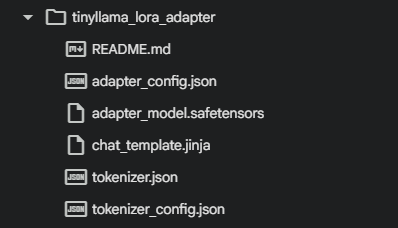

This saves ONLY:

LoRA adapter weights

NOT the entire TinyLlama model.


In [ ]:
!zip -r tinyllama_lora_adapter.zip tinyllama_lora_adapter

  adding: tinyllama_lora_adapter/ (stored 0%)
  adding: tinyllama_lora_adapter/tokenizer.json (deflated 85%)
  adding: tinyllama_lora_adapter/adapter_model.safetensors (deflated 7%)
  adding: tinyllama_lora_adapter/tokenizer_config.json (deflated 46%)
  adding: tinyllama_lora_adapter/chat_template.jinja (deflated 60%)
  adding: tinyllama_lora_adapter/README.md (deflated 65%)
  adding: tinyllama_lora_adapter/adapter_config.json (deflated 58%)


# Inferencing model after training

In [ ]:
from peft import PeftModel

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
)

fine_tuned_model = PeftModel.from_pretrained(
    base_model,
    "tinyllama_lora_adapter"
)

tokenizer = AutoTokenizer.from_pretrained(
    "tinyllama_lora_adapter"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
prompt = """
### Instruction:
What is the use of transformers in deep learning?

### Context:
NLP and AI models

### Response:
"""

In [ ]:
inputs = tokenizer(prompt,return_tensors="pt").to(model.device)

In [ ]:
output = fine_tuned_model.generate(**inputs,max_new_tokens=100)

In [ ]:
response = tokenizer.decode(output[0],skip_special_tokens=True)

print(response)


### Instruction:
What is the use of transformers in deep learning?

### Context:
NLP and AI models

### Response:
Transformers are used in NLP and AI models to perform sequence-to-sequence tasks. They are used to perform sequence-to-sequence tasks such as machine translation, question answering, and natural language processing. Transformers are used to perform sequence-to-sequence tasks because they can be trained on large amounts of data and can perform tasks that are difficult for humans to perform.



# creating gradio app

In [ ]:
!pip install gradio


In [ ]:
def chat(user_input):
    prompt = f"""
### Instruction:
{user_input}

### Context:

### Response:
"""

    inputs = tokenizer(prompt,return_tensors="pt").to(model.device)

    outputs = model.generate(**inputs,max_new_tokens=200)

    output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    response = output_text.split("### Response:")[-1].strip()

    return response

In [ ]:
import gradio as gr

In [ ]:
interface = gr.Interface(
    fn=chat,
    inputs=gr.Textbox(lines=3, placeholder="Ask something..."),
    outputs="text",
    title="TinyLlama Fine-Tuned Chatbot",
    description="Chatbot trained using LoRA on Dolly dataset"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ca32f7be3546e7b727.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
